In [1]:
import sys
sys.path.append('/gpfs/work/aac/xingyiyao23/Code/')
import SimpleITK as sitk
import glob
import os
import glob
import lpips
import torch
import numpy as np
import pandas as pd
import nibabel as nb
from skimage.metrics import structural_similarity
import matplotlib.pyplot as plt


import Diffusion_denoising_thin_slice.functions_collection as ff
import Diffusion_denoising_thin_slice.Build_lists.Build_list as Build_list

/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
build_sheet =  Build_list.Build(os.path.join('/gpfs/work/aac/xingyiyao23/Data/low_dose_CT/Patient_lists/mayo_low_dose_CT_gaussian_simulation_v2.xlsx'))
batch_list, patient_id_list, random_num_list,noise_file_all_list, noise_file_odd_list, noise_file_even_list, ground_truth_file_list, slice_num_list = build_sheet.__build__(batch_list = ['test']) 
n = ff.get_X_numbers_in_interval(total_number = patient_id_list.shape[0],start_number = 0,end_number = 1, interval = 1)

In [3]:
def calc_mae_with_ref_window(img, ref, vmin, vmax):
    maes = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        mae = np.sum(np.abs(slice_img - slice_ref) * mask) / np.sum(mask)
        maes.append(mae)

    return np.mean(maes), np.std(maes)

def calc_ssim_with_ref_window(img, ref, vmin, vmax):

    ssims = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        _, ssim_map = structural_similarity(slice_img, slice_ref, data_range=vmax - vmin, full=True)
        ssim = np.sum(ssim_map * mask) / np.sum(mask)
        ssims.append(ssim)

    return np.mean(ssims), np.std(ssims)

def calc_lpips(imgs1, imgs2, vmin, vmax):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    loss_fn = lpips.LPIPS().to(device)
    
    lpipss = []
    for slice_num in range(0, imgs1.shape[-1]):
        slice1 = imgs1[:,:,slice_num]
        slice2 = imgs2[:,:,slice_num]

        slice1 = np.clip(slice1, vmin, vmax).astype(np.float32)
        slice2 = np.clip(slice2, vmin, vmax).astype(np.float32)

        slice1 = (slice1 - vmin) / (vmax - vmin) * 2 - 1
        slice2 = (slice2 - vmin) / (vmax - vmin) * 2 - 1

        slice1 = np.stack([slice1, slice1, slice1], axis=-1)
        slice2 = np.stack([slice2, slice2, slice2], axis=-1)
        # print('after stack, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = np.transpose(slice1, (2, 0, 1))[np.newaxis, ...]
        slice2 = np.transpose(slice2, (2, 0, 1))[np.newaxis, ...]
        # print('after transpose, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = torch.from_numpy(slice1).to(device)
        slice2 = torch.from_numpy(slice2).to(device)

        lpips_val = loss_fn(slice1, slice2)
        lpipss.append(lpips_val.item())

      

    return np.mean(lpipss), np.std(lpipss)


# get metrics curve according to number of inferences

In [ ]:
# num_inferences = [1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

# mae_list = []
# ssim_list = []

# for i in range(0, len(num_inferences)):
#     n_infer = num_inferences[i]
#     print(f'Number of inferences: {n_infer}')

#     mae_for_this_infer = []
#     ssim_for_this_infer = []

#     for j in range(0, len(n)):

#         patient_id = patient_id_list[n[j]]
#         random_n = random_num_list[n[j]]
#         print(patient_id,  random_n)

#         # reference image
#         gt_file = os.path.join('/gpfs/work/aac/xingyiyao23/Data/low_dose_CT/nii_imgs', patient_id,  'img.nii.gz')
#         gt_img = nb.load(gt_file).get_fdata()[...,100:200]

#         # # our method 
#         # if n_infer != 1:
#         unsupervised_beta0_avg_file = os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_mayo/pred_images_input_both', patient_id,'random_'+str(random_n), 'epoch105avg/pred_img_scans' + str(n_infer) + '.nii.gz')
#         unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()
#         # else:
#         #     unsupervised_beta0_avg_file = os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_2/pred_images_input_both', patient_id,'random_'+str(random_n), 'epoch105_1/pred_img.nii.gz')
#         #     unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()

#         vmin = -160
#         vmax = 240
#         mae_case,_= calc_mae_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
#         ssim_case, _ = calc_ssim_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
#         print(f'MAE: {mae_case}, SSIM: {ssim_case}')

#         mae_for_this_infer.append(mae_case)
#         ssim_for_this_infer.append(ssim_case)
#     print('mae for this inference:', mae_for_this_infer, 'ssim for this inference:', ssim_for_this_infer)

#     mae_list.append(np.mean(mae_for_this_infer))
#     ssim_list.append(np.mean(ssim_for_this_infer))

# # save it into a dataframe
# df = pd.DataFrame({'num_inferences': num_inferences, 'MAE': mae_list, 'SSIM': ssim_list})
# df.to_excel('/host/d/projects/denoising/results/multiple_inference_analysis_mayo.xlsx', index=False)


Number of inferences: 1
L192 0
MAE: 15.111501356240336, SSIM: 0.6535403377152628
L143 0
MAE: 15.331362832293586, SSIM: 0.6555363660265094
L291 0
MAE: 17.888485959540677, SSIM: 0.630090305162075
mae for this inference: [15.111501356240336, 15.331362832293586, 17.888485959540677] ssim for this inference: [0.6535403377152628, 0.6555363660265094, 0.630090305162075]
Number of inferences: 2
L192 0
MAE: 12.89859757702574, SSIM: 0.7095083554442209
L143 0
MAE: 13.454804848233183, SSIM: 0.700866499103942
L291 0
MAE: 15.58350068074746, SSIM: 0.6806637321531696
mae for this inference: [12.89859757702574, 13.454804848233183, 15.58350068074746] ssim for this inference: [0.7095083554442209, 0.700866499103942, 0.6806637321531696]
Number of inferences: 3
L192 0
MAE: 12.066658796123527, SSIM: 0.7321508397139143
L143 0
MAE: 12.75612205140309, SSIM: 0.7186162302779961
L291 0
MAE: 14.731173086220997, SSIM: 0.7006971289148022
mae for this inference: [12.066658796123527, 12.75612205140309, 14.731173086220997

In [6]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [18]:
## load data
data = pd.read_excel('/host/d/projects/denoising/results/multiple_inference_analysis_mayo.xlsx')
num_inferences = data['num_inferences'].values
mae_list = data['MAE'].values
ssim_list = data['SSIM'].values

### mae

In [42]:
x = np.asarray(num_inferences)
y = np.asarray(mae_list)


def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（增加maxfev确保收敛，与原代码一致）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线的x/y值（更密集的x_fit确保曲线平滑）
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²（与原代码一致）
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))

# 计算幂律拟合的极限值（与原代码一致）
y_limit_pow = power_func(20, *popt_pow)
print('for power law, the limit of y when x is very large is:', y_limit_pow)

for power law, the limit of y when x is very large is: 11.688101370283519


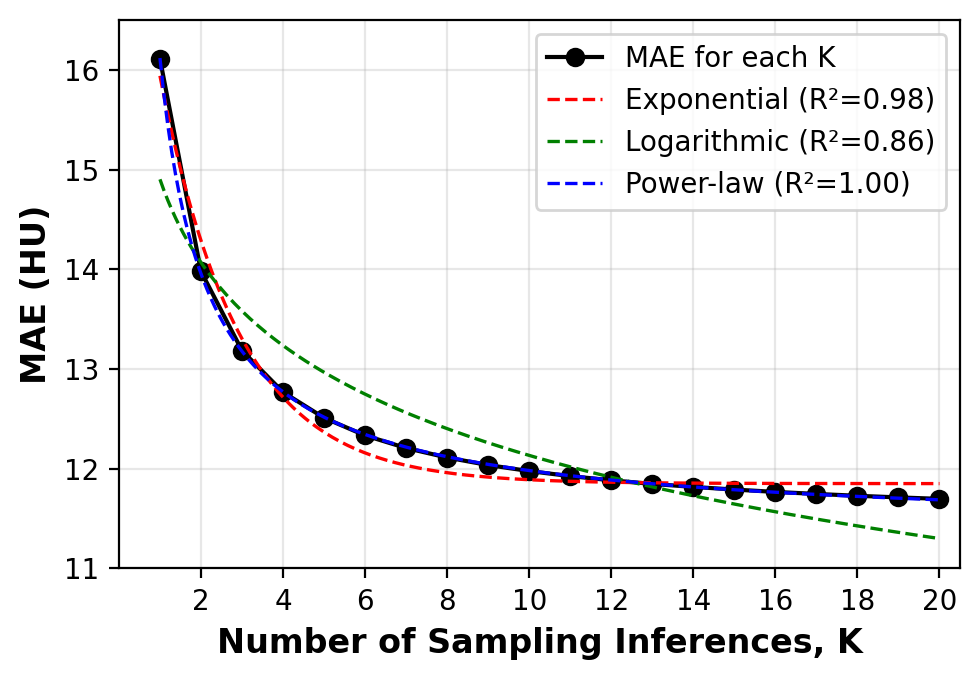

In [44]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)  # 用ax对象更易控制坐标轴

# 1. 绘制原始数据点与拟合曲线（保留原样式）
ax.plot(x, y, 'ko-', label='MAE for each K', linewidth=1.5, markersize=6)  # 黑色圆点+实线
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)  # 红色虚线
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)  # 绿色虚线
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)  # 蓝色虚线

# 2. 绘制FBP数据点（灰色圆点，K=1右侧，x=1.5避免重叠）
# fbp_mae = 16.7
# ax.plot(1.5, fbp_mae, 'o', color='red', markersize=6, label=f'FBP (MAE={fbp_mae} HU)')

# 3. 调整x轴：范围1-20，刻度2/4...20
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))  # 从2开始，间隔2到20
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. 调整y轴：范围11-17，刻度11/12...17
ax.set_ylim(11, 16.5)
ax.set_yticks(np.arange(11, 17, 1))  # 从11开始，间隔1到17
ax.set_ylabel('MAE (HU)', fontsize=12, fontweight='bold')

# 5. 保留网格与图例（原样式优化）
ax.grid(True, alpha=0.3, linestyle='-')  # 网格线透明度降低，更清晰
ax.legend(fontsize=10, frameon=True, loc='upper right')  # 图例位置右上，带边框


# -------------------------- 4. 保存/显示图片 --------------------------
plt.tight_layout()  # 避免标签截断
# plt.savefig('mae_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()  # 调试时取消注释
plt.savefig('/host/d/projects/denoising/results/mae_K_fitting_mayo.pdf', dpi=300, bbox_inches='tight')

### SSIM

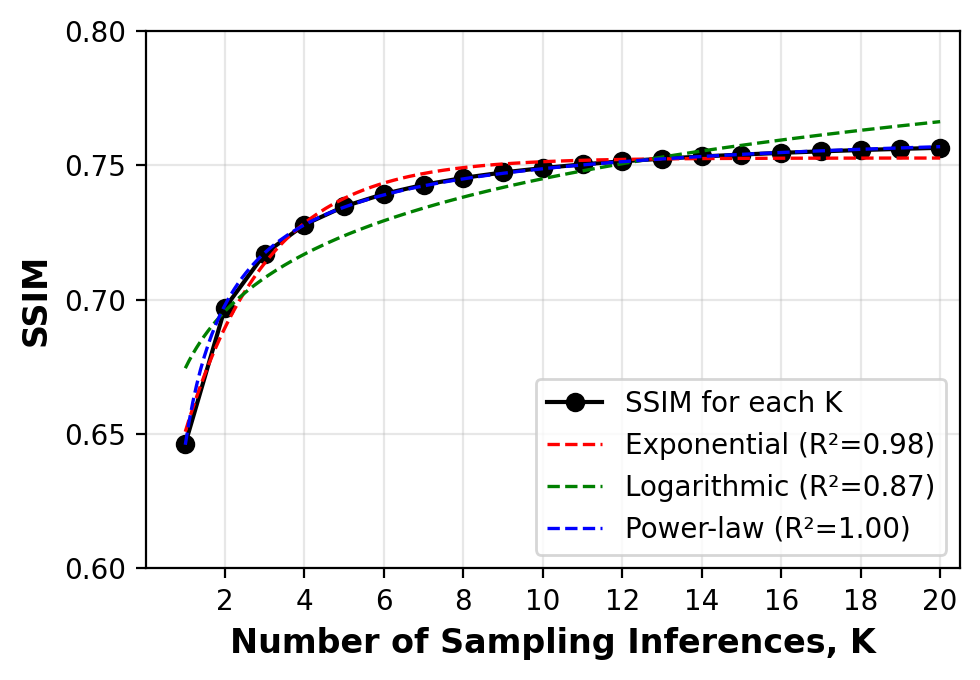

In [45]:
y = np.asarray(ssim_list)  # y轴为SSIM


# -------------------------- 2. 定义拟合函数与曲线拟合（逻辑不变） --------------------------
def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（SSIM是上升趋势，拟合参数会自动适配）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))


# -------------------------- 3. 绘图配置（适配SSIM的y轴范围） --------------------------
fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

# 1. 绘制原始数据与拟合曲线
ax.plot(x, y, 'ko-', label='SSIM for each K', linewidth=1.5, markersize=6)
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)

# 2. 绘制FBP的SSIM数据点（参考你之前表格的FBP SSIM值：0.744）
# fbp_ssim = 0.744  # 对应FBP的SSIM值
# ax.plot(1.5, fbp_ssim, 'o', color='gray', markersize=6, label=f'FBP (SSIM={fbp_ssim})')

# 3. 调整x轴（与之前一致）
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. 调整y轴（适配SSIM范围：假设数据在0.7~0.85之间）
ax.set_ylim(0.6, 0.80)
ax.set_yticks(np.arange(0.6, 0.81, 0.05))  # 刻度间隔0.05
ax.set_ylabel('SSIM', fontsize=12, fontweight='bold')

# 5. 网格与图例
ax.grid(True, alpha=0.3, linestyle='-')
ax.legend(fontsize=10, frameon=True, loc='lower right')  # 图例移至右下（适配SSIM上升趋势）


# -------------------------- 4. 保存图片 --------------------------
plt.tight_layout()
# plt.savefig('ssim_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.savefig('/host/d/projects/denoising/results/ssim_K_fitting_mayo.pdf', dpi=300, bbox_inches='tight')